In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "stsb"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 5749
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'A plane is taking off.',
 'sentence2': 'An air plane is taking off.',
 'label': 5.0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1']

'Some men are fighting.'

In [11]:
raw_train_dataset[5]['sentence2']

'Two men are fighting.'

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': Value('float32'),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1379
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 66]),
 'token_type_ids': torch.Size([32, 66]),
 'attention_mask': torch.Size([32, 66])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
num_labels = 1

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(4.9161, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(10.6868, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda')

### Load Trained Weights

In [29]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [30]:
from train_eval_func import eval_loop

In [31]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [32]:
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [33]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

# 5. FFN Drop

In [34]:
from layer_drop import layer_drop

In [35]:
from layer_merge_helper import reorder_merged_layer_heads, reorder_merged_layer_neurons

In [36]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [37]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)
  Layer 6: Registered masks (12 heads, 3072 neurons)
  Layer 7: Registered masks (12 heads, 3072 neurons)
  Layer 8: Registered masks (12 heads, 3072 neurons)
  Layer 9: Registered masks (12 heads, 3072 neurons)
  Layer 10: Registered masks (12 heads, 3072 neurons)
  Layer 11: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [39]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [03:41<00:00,  1.92s/it]

  Reps Similarity Stats:
    Average: 0.924553
    Highest: 0.993618
    Lowest:  0.547637

  Atts Similarity Stats:
    Average: 0.935507
    Highest: 0.992367
    Lowest:  0.783654
  Sublayer Similarity Stats:
    Average: 0.361834
    Highest: 0.657522
    Lowest:  0.185416


In [39]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

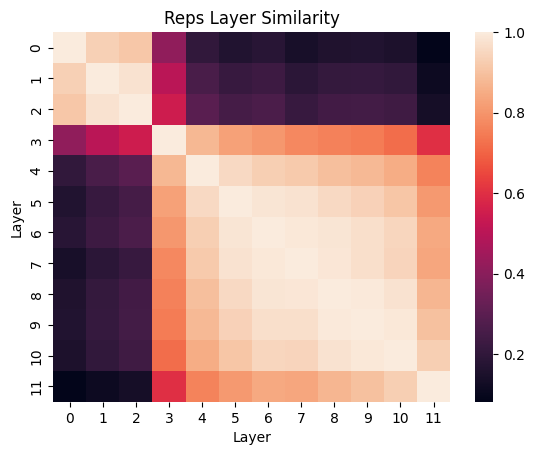

In [41]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

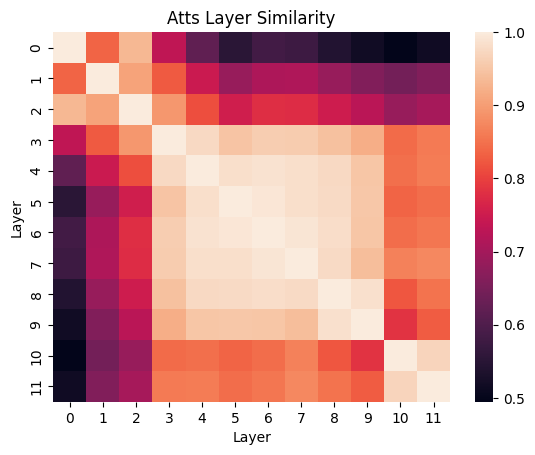

In [42]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [43]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 180/180 [00:34<00:00,  5.15it/s]


In [44]:
layer_scores = torch.tensor([
    h.mean().item()
    for h in head_importance
])

print(layer_scores.shape)
print(layer_scores)

torch.Size([12])
tensor([4.4982e-06, 3.9681e-06, 6.0533e-06, 7.2031e-06, 4.7330e-06, 7.1869e-06,
        3.3133e-06, 2.7440e-06, 4.5807e-06, 4.6696e-06, 3.5156e-06, 5.0097e-06])


In [45]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.3934, 0.2745, 0.7421, 1.0000, 0.4460, 0.9964, 0.1277, 0.0000, 0.4119,
        0.4318, 0.1730, 0.5081])

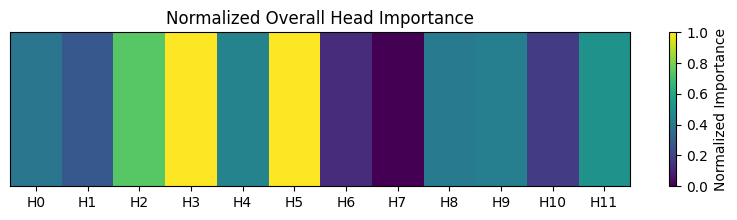

In [46]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [47]:
neuron_layer_scores = torch.tensor([
    h.mean().item()
    for h in neuron_importance
])

print(neuron_layer_scores.shape)
print(neuron_layer_scores)

torch.Size([12])
tensor([1.5256e-07, 1.6192e-07, 1.8233e-07, 2.0381e-07, 2.1962e-07, 1.9473e-07,
        1.6965e-07, 1.7615e-07, 1.8696e-07, 1.8033e-07, 1.7263e-07, 1.4455e-07])


In [48]:
neuron_normalized_scores = (
    (neuron_layer_scores - neuron_layer_scores.min())
    / (neuron_layer_scores.max() - neuron_layer_scores.min())
)
neuron_normalized_scores

tensor([0.1067, 0.2314, 0.5033, 0.7895, 1.0000, 0.6684, 0.3344, 0.4210, 0.5650,
        0.4766, 0.3740, 0.0000])

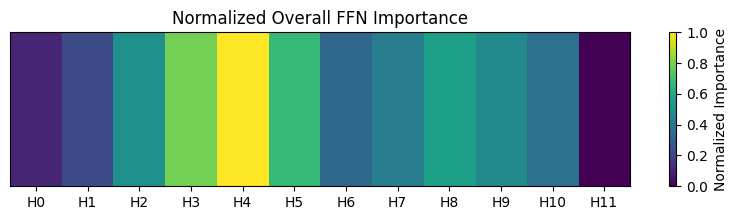

In [49]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    neuron_normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()

In [50]:
def layer_score(importance):
    layer_scores = torch.tensor([
        h.mean().item()
        for h in importance
    ])

    normalized_scores = (
        (layer_scores - layer_scores.min())
        / (layer_scores.max() - layer_scores.min())
    )
    
    return normalized_scores

In [51]:
layer_score(neuron_importance)

tensor([0.1067, 0.2314, 0.5033, 0.7895, 1.0000, 0.6684, 0.3344, 0.4210, 0.5650,
        0.4766, 0.3740, 0.0000])

In [40]:
def compute_merge_scaling_factors(mean_score):

    if mean_score < 0.3:
        head_addition = 0
        ffn_multiplier = 1.0

    elif mean_score < 0.6:
        head_addition = 2
        ffn_multiplier = 1.2

    elif mean_score < 0.8:
        head_addition = 4
        ffn_multiplier = 1.5

    elif mean_score <= 1.0:
        head_addition = 6
        ffn_multiplier = 1.7

    else:
        raise ValueError("mean_score must be <= 1.0")

    return head_addition, ffn_multiplier

In [53]:
# from layer_drop import ffn_drop

In [41]:
from train_eval_func import get_primary_metric, set_lr_scheduler, train
from layer_drop import prune_mlp
from layer_merge_helper import merge_mha, merge_ff
from torch.optim import AdamW
import os

In [42]:
def ffn_drop(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    init_metric,
    cka_evaluator=None,
    num_merges=6,
    target_layers=[3, 4, 5, 6, 7],
    recovery_epochs=10,
    recovery_lr=1e-5,
    patience=2,
    save_dir='./weights/',
    keep_temp_checkpoints=False,
    cka_max_iter=float("Inf"),
    imp_score_max_batches=float("Inf"),
    teacher_model=None,
    alpha=0.5,
    temperature=6,
    drop_strategy="top",
    iterations=9,
    regression=False
):
    recovery_dir = save_dir
    save_dir = save_dir + drop_strategy+ "/"
    
    target_metric = get_primary_metric(task_name)
    threshold = init_metric[target_metric] * 0.01

    # Create recovery checkpoint directory
    recovery_dir = os.path.join(recovery_dir, 'recovery')
    os.makedirs(recovery_dir, exist_ok=True)
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"Target Metric for {task_name}: {target_metric}")
    print(f"Original {target_metric} score: {init_metric[target_metric]:.4f}")
    print(f"Recovery threshold: {threshold:.4f}")
    print("")

    performance_track = []
    remaining_layers = []
    
    performance_track.append(init_metric)
    for iteration in range(iterations):
        print(" --> Iteration:", iteration + 1)
        n_layer = 12 - iteration - 1
        
        if drop_strategy == "top":    
            prune_mlp(model, n_layer)
        elif drop_strategy == "alt":
            if iterations > 6:
                print("Iterations specified too high")
                return
            target_layers = [11, 9, 7, 5, 3, 1]
            prune_mlp(model, target_layers[iteration])
        elif drop_strategy == "similarity_merge":
            #### selecting very similar layers (both still have mlps)
            cls_reps_similarity = cka_eval.pairwise(
                model, 
                train_dataloader, 
                device, 
                only_cls_token=True, 
                max_iter=130
            )

            adj_similarities = []
            for i in range(1, len(cls_reps_similarity)):
                adj_similarities.append(cls_reps_similarity[i-1][i])

            high_sim_indices = []
            for idx, value in enumerate(adj_similarities):
                if (
                    value > 0.8
                    and model.bert.encoder.layer[idx].int_mask_param is not None
                    and model.bert.encoder.layer[idx + 1].int_mask_param is not None
                ):
                    high_sim_indices.append(idx)

            if len(high_sim_indices) == 0:
                print("No highly similar layer pairs found.")
                break

            #### selecting weakest similar layer
            head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

            # normalizing ffn neuron scores
            neuron_layer_scores = torch.tensor([
                h.mean().item() if h is not None else 0.0
                for h in neuron_importance
            ])
            neuron_normalized_scores = (
                (neuron_layer_scores - neuron_layer_scores.min())
                / (neuron_layer_scores.max() - neuron_layer_scores.min())
            )

            # selecting weaskest sensitive pair
            PROTECTED_THRESHOLD = 0.8

            min_idx, min_score = None, float('inf')
            for idx in high_sim_indices:
                mlp1_sen_score = float(neuron_normalized_scores[idx])
                mlp2_sen_score = float(neuron_normalized_scores[idx+1])

                # # protect only when BOTH are highly sensitive
                if (
                    mlp1_sen_score > PROTECTED_THRESHOLD
                    or mlp2_sen_score > PROTECTED_THRESHOLD
                ):
                    continue
                
                mean_score = (mlp1_sen_score + mlp2_sen_score) / 2
                if mean_score < min_score:
                    min_score = mean_score
                    min_idx = idx

            if min_idx == None:
                print("No highly similar layer pairs below protected threshold found.")
                break
            
            print(f"Selected Pair: {min_idx}, {min_idx + 1}")
            # print(min_score)

            # determining scaling for attention heads and FFN neurons for the merged layer
            head_addition, ffn_multiplier = compute_merge_scaling_factors(min_score)
            print(head_addition, ffn_multiplier)
            
            # determining to merge in merge or later layer
            ratio = (
                neuron_normalized_scores[min_idx + 1]
                / (neuron_normalized_scores[min_idx] + 1e-8)
            )
            if ratio < 0.3:
                # layer2 much weaker
                # direction = "into_former"
                source_layer = min_idx + 1
                target_layer = min_idx
            else:
                # normal case
                # direction = "into_latter"
                source_layer = min_idx
                target_layer = min_idx + 1

            # head_imp1, indices1 = torch.sort(head_importance[source_layer], descending=True)
            # head_imp2, indices2 = torch.sort(head_importance[target_layer], descending=True)
    
            neuron_imp1, indices1 = torch.sort(neuron_importance[source_layer], descending=True)        
            neuron_imp2, indices1 = torch.sort(neuron_importance[target_layer], descending=True)

            max_width = max(
                model.bert.encoder.layer[source_layer].int_mask_param.shape[0], 
                model.bert.encoder.layer[target_layer].int_mask_param.shape[0]
            )

            extra_neurons = int(max_width * (ffn_multiplier - 1))

            merge_ff(
                model, model.bert.encoder.layer[source_layer], model.bert.encoder.layer[target_layer], 
                neuron_imp1, neuron_imp2, device, extra_neurons=extra_neurons
            )
            prune_mlp(model, source_layer)
            print(f"Layer {source_layer} pruned!")

            torch.cuda.empty_cache()
            # return
        else:
            print("Please choose correct MLP dropping strategy")
            return
        
        print("Number of Remaining MLPs:", n_layer)
    
        # Post Drop Performance 
        eval_metric = eval_loop(model, val_dataloader, task_name, device, regression=regression)[0]
        
        print("  Post Operation Metrics:")
        for metric_name, value in eval_metric.items():
            marker = "★" if metric_name == target_metric else " "
            print(f"    {marker} {metric_name}: {value:.4f}")

    
        # Recovery Training
        diff = init_metric[target_metric] - eval_metric[target_metric]
        print(f"  Performance drop: {diff:.4f} (threshold: {threshold:.4f})")

        is_retrained = False
        if diff > threshold:
            print("  → Recovery training NEEDED")

            # Setup optimizer and scheduler
            optimizer = AdamW(model.parameters(), lr=recovery_lr)
            num_training_steps = recovery_epochs * len(train_dataloader)
            lr_scheduler = set_lr_scheduler(
                optimizer=optimizer,
                num_training_steps=num_training_steps
            )
            
            print(f"  → Training: {recovery_epochs} epochs, lr={recovery_lr}")
            
            # Temporary checkpoint path
            temp_save_path = os.path.join(recovery_dir, f'temp_iter{iteration}-{task_name}.pt')
            
            # Train with checkpoint saving
            # lr_scheduler= None
            train_stats = train(
                model,
                train_dataloader,
                val_dataloader,
                task_name,
                device,
                num_epochs=recovery_epochs,
                lr=recovery_lr,
                patience=patience,
                use_early_stopping=True,
                optimizer=optimizer,
                lr_scheduler=lr_scheduler,
                save_path=temp_save_path,
                display_epoch_iter=True,
                regression=regression,
                teacher_model=teacher_model, alpha=alpha, temperature=temperature
            )

             # CRITICAL: Reload best checkpoint
            print("\n  → Loading best checkpoint...")
            best_checkpoint = torch.load(temp_save_path)
            model.load_state_dict(best_checkpoint['model_state_dict'])
            
            print(f"  ✓ Loaded best checkpoint from epoch {best_checkpoint['epoch']}")
            print(f"    Best val loss: {best_checkpoint['val_loss']:.4f}")
            print(f"    Best val metrics: {best_checkpoint['val_metrics']}")
            
            # merge_history['metrics_after_recovery'].append(best_checkpoint['val_metrics'])
            # merge_history['training_stats'].append(train_stats)
            
            # Clean up temp checkpoint if not keeping
            if not keep_temp_checkpoints:
                os.remove(temp_save_path)
                print(f"  ✓ Cleaned up temporary checkpoint")

            is_retrained = True
        else:
            print("  → Recovery training NOT needed")

        eval_metric = eval_loop(model, val_dataloader, task_name, device, regression=regression)[0]
        performance_track.append(eval_metric)

        if n_layer in target_layers:
            save_path = os.path.join(save_dir, f'layer-{n_layer}-{task_name}.pt')
            
            save_object = {
                'model_state_dict': model.state_dict(),
                # 'layer_track': tracker.get_mapping(),
                # 'train_stats': merge_history['training_stats'][-1],
                # 'metrics_after_merge': merge_history['metrics_after_merge'][-1],
                # 'metrics_after_recovery': merge_history['metrics_after_recovery'][-1],
                'merge_iteration': iteration + 1,
                'num_layers': n_layer,
                'is_retrained': is_retrained
            }
            
            torch.save(save_object, save_path)
            print(f"  ✓ Saved {n_layer}-layer model to {save_path}")
        else:
            print(f"  • {n_layer} layers (not in target list, skipping save)")

        print("")

    return_obj = {
        "performance_track": performance_track,
        "remaining_layers": remaining_layers
    }

    return return_obj

In [43]:
init_metric = eval_loop(model, val_dataloader, task_name, device, regression=True)[0]
init_metric

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [44]:
performance_track = ffn_drop(
    model, train_dataloader, val_dataloader, task_name, device, init_metric=init_metric, num_merges=9,
    cka_evaluator=cka_eval, teacher_model=teacher_model, drop_strategy="similarity_merge", recovery_lr=1e-5,
    iterations=8, regression=True
)

Target Metric for stsb: pearson
Original pearson score: 0.9001
Recovery threshold: 0.0090

 --> Iteration: 1


Computing importance (heads + FFN): 100%|██████████| 180/180 [00:15<00:00, 11.28it/s]


Selected Pair: 0, 1
0 1.0
1367 1705
Layer 0 pruned!
Number of Remaining MLPs: 11
  Post Operation Metrics:
    ★ pearson: 0.6797
      spearmanr: 0.6876
  Performance drop: 0.2203 (threshold: 0.0090)
  → Recovery training NEEDED
  → Training: 10 epochs, lr=1e-05


Training:   0%|          | 0/1800 [00:00<?, ?it/s]

Knowledge distillation used!


...

Training: 100%|██████████| 1800/1800 [09:43<00:00,  3.09it/s]

✓ Saved checkpoint (best loss: 0.4984)

<----------------- Epoch 10 ----------------->
Loss: 0.05, Training Metrics:
  pearson: 0.9783
  spearmanr: 0.9739
Validation Loss: 0.5, Validation Metrics:
  pearson: 0.8930
  spearmanr: 0.8896
Elapsed Time: 32.0859 sec

Total Training Time: 583.02 sec
Chosen Primary Metric: pearson
Best Metric Run: 0.8930

  → Loading best checkpoint...


  ✓ Loaded best checkpoint from epoch 10
    Best val loss: 0.4984
    Best val metrics: {'pearson': 0.8929936227556001, 'spearmanr': 0.8895616433543733}
  ✓ Cleaned up temporary checkpoint
  • 11 layers (not in target list, skipping save)

 --> Iteration: 2


Computing importance (heads + FFN): 100%|██████████| 180/180 [00:15<00:00, 11.77it/s]

No highly similar layer pairs below protected threshold found.


In [45]:
model.bert.encoder.layer

ModuleList(
  (0): BertLayer(
    (attention): BertAttention(
      (self): BertSelfAttention(
        (query): Linear(in_features=768, out_features=768, bias=True)
        (key): Linear(in_features=768, out_features=768, bias=True)
        (value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (output): BertSelfOutput(
        (dense): Linear(in_features=768, out_features=768, bias=True)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (intermediate): None
    (output): BertOutput(
      (dense): None
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (1-11): 11 x BertLayer(
    (attention): BertAttention(
      (self): BertSelfAttention(
        (query): Linear(in_features=768, out_features=768, bias=True)
        (key): Linear(in_features=768,

In [57]:
torch.save(performance_track, f'./weights/alt/performance_track_{task_name}.pt')

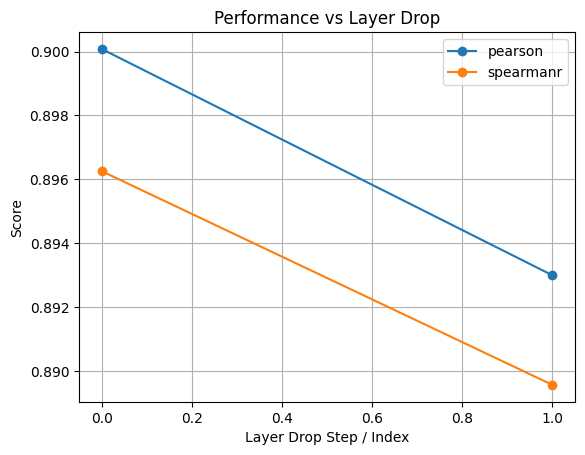

In [46]:
performance_track = performance_track['performance_track']

# get all metric names dynamically
metrics = performance_track[0].keys()

x = list(range(len(performance_track)))  # e.g., layer index or drop step

plt.figure()

for metric in metrics:
    y = [entry.get(metric, None) for entry in performance_track]
    plt.plot(x, y, marker='o', label=metric)

plt.xlabel("Layer Drop Step / Index")
plt.ylabel("Score")
plt.title("Performance vs Layer Drop")
plt.legend()
plt.grid()

plt.show()

In [47]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [01:36<00:00,  1.20it/s]

  Reps Similarity Stats:
    Average: 0.912198
    Highest: 0.990976
    Lowest:  0.751004

  Atts Similarity Stats:
    Average: 0.902565
    Highest: 0.994507
    Lowest:  0.587043
  Sublayer Similarity Stats:
    Average: 0.370985
    Highest: 0.576248
    Lowest:  0.197105


Text(50.722222222222214, 0.5, 'Layer')

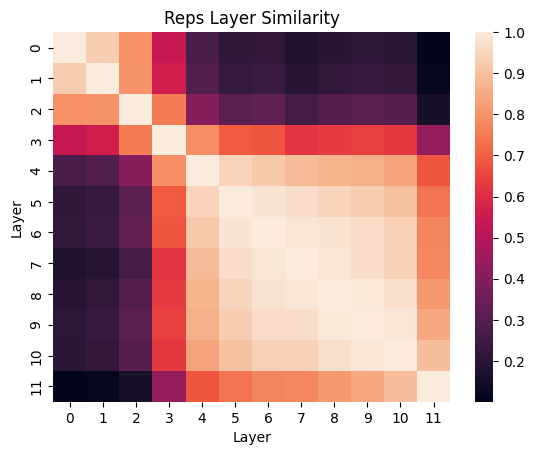

In [48]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

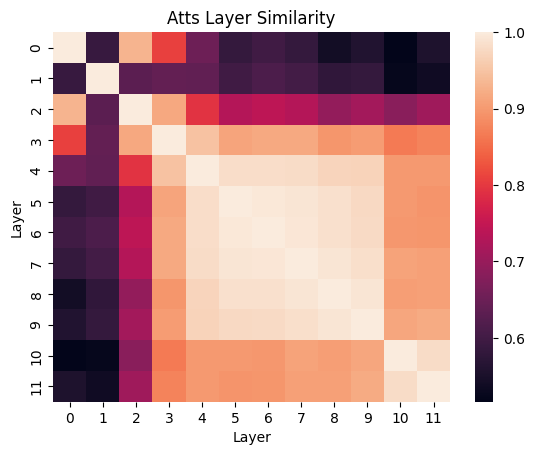

In [49]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [50]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 180/180 [00:32<00:00,  5.55it/s]


In [51]:
layer_scores = torch.tensor([
    h.mean().item()
    for h in head_importance
])

print(layer_scores.shape)
print(layer_scores)

torch.Size([12])
tensor([7.6707e-06, 7.5917e-06, 5.3988e-06, 7.2401e-06, 5.2631e-06, 6.2129e-06,
        3.6016e-06, 3.6663e-06, 6.7580e-06, 8.4288e-06, 5.6324e-06, 8.8479e-06])


In [52]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)
normalized_scores

tensor([0.7756, 0.7606, 0.3426, 0.6935, 0.3167, 0.4977, 0.0000, 0.0123, 0.6016,
        0.9201, 0.3871, 1.0000])

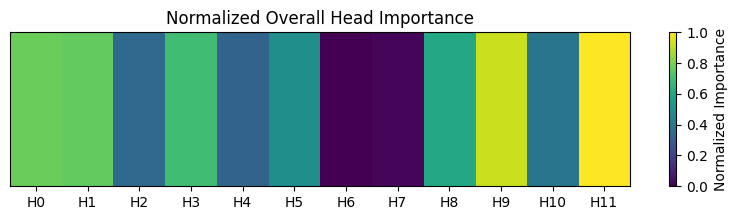

In [53]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall Head Importance")

plt.show()

In [54]:
neuron_layer_scores = torch.tensor([
    h.mean().item() if h is not None else 0.0
    for h in neuron_importance
])

print(neuron_layer_scores.shape)
print(neuron_layer_scores)

torch.Size([12])
tensor([0.0000e+00, 2.1114e-07, 2.4397e-07, 2.3371e-07, 2.4300e-07, 2.2832e-07,
        2.2054e-07, 2.3993e-07, 2.6568e-07, 2.5927e-07, 2.5554e-07, 1.7644e-07])


In [55]:
neuron_normalized_scores = (
    (neuron_layer_scores - neuron_layer_scores.min())
    / (neuron_layer_scores.max() - neuron_layer_scores.min())
)
neuron_normalized_scores

tensor([0.0000, 0.7947, 0.9183, 0.8797, 0.9146, 0.8594, 0.8301, 0.9031, 1.0000,
        0.9759, 0.9618, 0.6641])

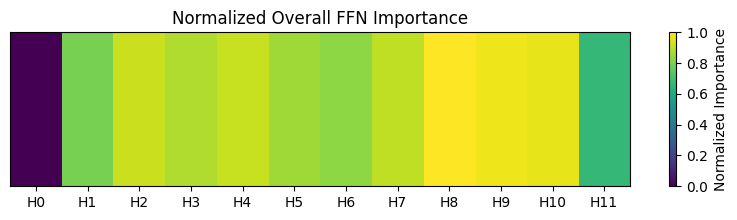

In [56]:
plt.figure(figsize=(10, 2))

im = plt.imshow(
    neuron_normalized_scores.unsqueeze(0),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.xticks(range(12), [f"H{i}" for i in range(12)])
plt.yticks([])

plt.title("Normalized Overall FFN Importance")

plt.show()

In [57]:
from pathlib import Path

def compute_size(model):
    state_dict = model.state_dict()
    tmp_path = Path("model.pt")
    torch.save(state_dict, tmp_path)
    # Calculate size in megabytes
    size_mb = Path(tmp_path).stat().st_size / (1024 * 1024)
    # Delete temporary file
    tmp_path.unlink()
    print(f"Model size (MB) - {size_mb:.2f}")
    # return size_mb

In [58]:
compute_size(teacher_model)

Model size (MB) - 417.71


In [59]:
compute_size(model)

Model size (MB) - 358.36


In [60]:
import numpy as np

In [61]:
from time import perf_counter

def time_pipeline(model, dataloader, device):
    latencies = []
    
    # Warmup
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        model(**batch)
        break
        
    # Timed run
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        start_time = perf_counter()
        model(**batch)
        latency = perf_counter() - start_time
        latencies.append(latency)
    # Compute run statistics
    time_avg_ms = 1000 * np.mean(latencies)
    time_std_ms = 1000 * np.std(latencies)
    print(f"Average latency (ms) - {time_avg_ms:.2f} +\- {time_std_ms:.2f}")
    # return {"time_avg_ms": time_avg_ms, "time_std_ms": time_std_ms}

In [ ]:
time_pipeline(teacher_model, train_dataloader, device)

In [ ]:
time_pipeline(model, train_dataloader, device)

In [64]:
eval_loop(teacher_model, eval_dataloader, task_name, device)[0]

{'accuracy': 0.8133333333333334, 'f1': 0.8686786296900489}

In [65]:
eval_loop(model, eval_dataloader, task_name, device)[0]

{'accuracy': 0.8179710144927537, 'f1': 0.8699254349627175}